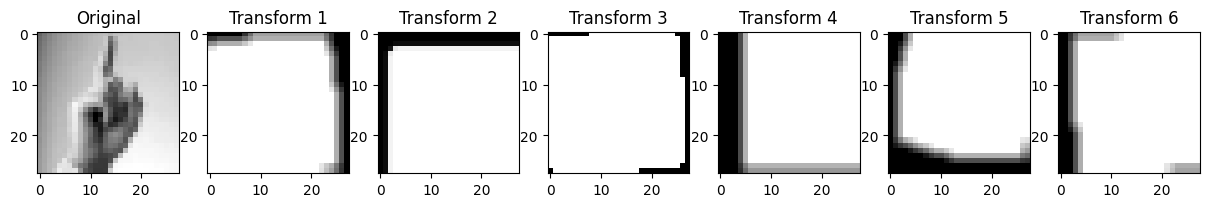

Época 1, Pérdida entrenamiento: 0.8225044275227639, Pérdida validación: 0.0876682895468548, Precisión validación: 96.95865962484065%
Época 2, Pérdida entrenamiento: 0.05485753542575863, Pérdida validación: 0.018203974634457682, Precisión validación: 99.52649790566382%
Época 3, Pérdida entrenamiento: 0.008454070527661615, Pérdida validación: 0.0007514270485888458, Precisión validación: 100.0%
Época 4, Pérdida entrenamiento: 0.0003449206870361818, Pérdida validación: 0.0003503914206301615, Precisión validación: 100.0%
Época 5, Pérdida entrenamiento: 0.00021238519399800483, Pérdida validación: 0.00028579563653227864, Precisión validación: 100.0%


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Parte 1: Transformaciones de Imágenes

# Cargar el dataset desde CSV
data = pd.read_csv('sign_mnist_train.csv')
labels = data['label']
data = data.drop(columns='label').to_numpy()  # Convertir los valores de los píxeles a un array de NumPy
images = data.reshape(-1, 28, 28).astype(np.float32)

# Seleccionar una imagen
image = images[0]  # Seleccionar la primera imagen
image_tensor = torch.tensor(image).unsqueeze(0)  # Añadir dimensión de canal

# Aplicar transformaciones a la imagen
transform = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomAffine(0, translate=(0.2, 0.2)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.5),
    transforms.GaussianBlur(3)
])

# Transformar la imagen varias veces
transformed_images = [transform(image_tensor) for _ in range(6)]

# Visualizar la imagen original y las transformadas
fig, axes = plt.subplots(1, 7, figsize=(15, 3))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original')

for i in range(6):
    axes[i + 1].imshow(transformed_images[i].squeeze(), cmap='gray')
    axes[i + 1].set_title(f'Transform {i + 1}')
    
plt.show()

# Parte 2: Exploración de la Red Convolucional

# Transformar las imágenes en tensores
tensor_images = torch.tensor(images).unsqueeze(1)
tensor_labels = torch.tensor(labels.values)

# Dividir los datos en entrenamiento (80%) y validación (20%)
train_images, val_images, train_labels, val_labels = train_test_split(
    tensor_images, tensor_labels, test_size=0.2, random_state=42
)

# Crear DataLoader para entrenamiento y validación
train_dataset = torch.utils.data.TensorDataset(train_images, train_labels)
val_dataset = torch.utils.data.TensorDataset(val_images, val_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# Definir una red convolucional básica
class CNNModel(nn.Module):
    def __init__(self, out_channels=32, kernel_size=3, stride=1, padding=1, pool_kernel=2, pool_stride=2):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(1, out_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        self.pool = nn.MaxPool2d(pool_kernel, pool_stride)
        self.conv2 = nn.Conv2d(out_channels, 64, kernel_size=kernel_size, padding=padding)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 25)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Crear una instancia del modelo
model = CNNModel()

# Definir el criterio de pérdida y el optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0005)

# Entrenamiento del modelo
for epoch in range(5):  # Entrenamiento por 5 épocas
    running_loss = 0.0
    model.train()
    
    # Entrenamiento
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    # Evaluación en conjunto de validación
    val_loss = 0.0
    correct = 0
    total = 0
    model.eval()
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    # Reportar precisión y pérdida en entrenamiento y validación
    print(f"Época {epoch+1}, Pérdida entrenamiento: {running_loss/len(train_loader)}, Pérdida validación: {val_loss/len(val_loader)}, Precisión validación: {100 * correct / total}%")

